In [3]:
import argparse
import os
import pickle
import sys
import typing

import pandas as pd
import torch
from Bio import SeqIO
from typing import List, Union, Optional, Callable, Sequence
from transformers import (
    EsmForMaskedLM, 
    PretrainedConfig, 
    EsmTokenizer, 
    DataCollatorForLanguageModeling, 
    Trainer
)

from tokenizers import Tokenizer
import torch
import torch.nn.functional as F

import einops
import yaml
import sys
import json
import functools
import os

import numpy as np
from huggingface_hub import hf_hub_download
from datasets import Dataset, load_dataset
import math

from matplotlib import pyplot as plt

/home/averma2/miniforge3/envs/exploratory_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
sys.path.append("../scripts")
from compute_node_embeddings import load_sequences, get_protein_sequence

In [10]:
device = "cuda"
CONTEXT_LEN = 1000

In [11]:
# ESM-2 config
with open("./plm_circuits/esm_config150M.json", "r") as file:
    esm_config = json.load(file)
model_name = esm_config["_name_or_path"]
model_name = model_name[model_name.find("facebook"):]
esm_config["token_dropout"] = False
esm_config["model_name"] = model_name
esm_config = PretrainedConfig(**esm_config)

# ESM-2 tokenizezr config
REPO_ID = esm_config.model_name
special_tokens_map_file = "special_tokens_map.json"
tokenizer_config = {}
tokenizer_config["vocab_file"] = hf_hub_download(repo_id=REPO_ID, filename="vocab.txt")
tokenizer_config["model_max_length"] = CONTEXT_LEN
with open(hf_hub_download(repo_id=REPO_ID, filename=special_tokens_map_file), "r") as f:
    tokenizer_config = {**tokenizer_config, **(json.load(f))}

In [12]:
# ESM-2
model_name = esm_config.model_name
print(model_name)

tokenizer = tokenizer = EsmTokenizer(**tokenizer_config)
reg_esm = EsmForMaskedLM(esm_config).to(device)

reg_esm_state_dict = torch.load(hf_hub_download(repo_id=REPO_ID, filename="pytorch_model.bin"))
# removing fixed position embedding
del reg_esm_state_dict["esm.embeddings.position_embeddings.weight"]
del reg_esm_state_dict["esm.embeddings.position_ids"]

print(reg_esm.load_state_dict(reg_esm_state_dict))

facebook/esm2_t30_150M_UR50D
<All keys matched successfully>


<img src="./plm_circuits/ESM2_architecture.png" width="1000"/>

## Perplexity of ESM on Uniref50 sequences

In [97]:
pathogen_perplexities = dict()

In [98]:
def tokenizer_for_map(seq, seq_key="input_ids"): #Tokenizer and params including special_tokens_mask required for MLM
    return tokenizer(
        seq[seq_key],
        return_tensors="pt", 
        return_special_tokens_mask=True,
        truncation=True,
        padding="max_length",
        max_length=1000,
    )

In [99]:
# load uniref50 test dataset (~50k seqs)
uniref50_ds = load_dataset("fredzzp/Uniref50", split="test")
column_names = uniref50_ds.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
uniref_tokenizer_map = functools.partial(tokenizer_for_map, seq_key="sequence")
uniref_dataset = uniref50_ds.map( 
        uniref_tokenizer_map,
        batched=True,
        num_proc=8,
        remove_columns=column_names,
    )
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

Map (num_proc=8): 100%|██████████████████████████████████████████████████████████████████| 48941/48941 [00:20<00:00, 2429.75 examples/s]


In [100]:
# small thing to turn off annoying wand questions
os.environ["WANDB_DISABLED"] = "true"

# evaluate ESM-2 model on uniref50 
evaluator = Trainer(
  model=reg_esm,
  data_collator=data_collator,
  eval_dataset=uniref_dataset[:800]["input_ids"],
)
uniref_results = evaluator.evaluate()

{'eval_loss': 2.098052978515625, 'eval_model_preparation_time': 0.0042, 'eval_runtime': 16.0733, 'eval_samples_per_second': 49.772, 'eval_steps_per_second': 6.222}


In [101]:
pathogen_perplexities["uniref50"] = math.exp(uniref_results['eval_loss'])
print(f"Uniref50 ESM-2 Perplexity: {pathogen_perplexities['uniref50']:.4f}\n")

Uniref50 ESM-2 Perplexity: 8.1503



## Perplexity of ESM on different pathogens

In [13]:
# data loading
with open("../config/pathogen_config.yaml", "r") as config_file:
    config = yaml.safe_load(config_file)
pathogens = list(config["pathogens"].keys())
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer,return_tensors='pt',mlm_probability=0.15)

In [56]:
# small thing to turn off annoying wand questions
os.environ["WANDB_DISABLED"] = "true"

for pathogen_name in pathogens:
    fasta_file = f"../../data/pathogen/{pathogen_name}/alignment.fasta"
    data = load_sequences(fasta_file)
    sequence_names, sequences = list(zip(*list(data.items())))
    uniq_seqs, unique_inds = np.unique(sequences, return_index=True) # For the purpose of eval, I only care about unique sequences 


    # identical code to how it's compute_node_embeddings.py
    protein_coords = config["pathogens"][pathogen_name]["protein_coords"]
    cut_seqs = [get_protein_sequence(x, protein_coords) for x in uniq_seqs]
    cut_seqs = list(np.unique([x for x in cut_seqs if len(x) > 3])) # remove any identical sequences again in case more appear after trimming

    # create dataset
    eval_dict = {"input_ids":list(cut_seqs)}

    eval_dset = Dataset.from_dict(eval_dict)

    column_names = eval_dset.column_names #This will be the names of all the old columns, to then be deleted after the new tokenized columns are added.
    eval_dataset = eval_dset.map( 
        tokenizer_for_map,
        batched=True,
        num_proc=8,
        remove_columns=column_names,
    )

    # evaluate ESM-2 model on dataset 
    evaluator = Trainer(
      model=reg_esm,
      data_collator=data_collator,
      eval_dataset=eval_dataset,
    )
    eval_results = evaluator.evaluate()
    pathogen_perplexities[pathogen_name] = math.exp(eval_results['eval_loss'])
    print(f"Pathogen: {pathogen_name}\nESM-2 Perplexity: {pathogen_perplexities[pathogen_name]:.4f}\n")

with open("pathogen_perplexities.json", "w") as file:
    json.dump(pathogen_perplexities, file)

Map (num_proc=8): 100%|███████████████████████████████████████████████████████████████████████| 971/971 [00:01<00:00, 823.89 examples/s]


{'eval_loss': 2.7814431190490723, 'eval_model_preparation_time': 0.0103, 'eval_runtime': 20.2339, 'eval_samples_per_second': 47.989, 'eval_steps_per_second': 6.029}
Pathogen: influenza_h3n2_ha
ESM-2 Perplexity: 16.1423



Map (num_proc=8): 100%|████████████████████████████████████████████████████████████████████| 1658/1658 [00:01<00:00, 1229.09 examples/s]


{'eval_loss': 2.283005475997925, 'eval_model_preparation_time': 0.0103, 'eval_runtime': 34.6572, 'eval_samples_per_second': 47.84, 'eval_steps_per_second': 6.002}
Pathogen: rsv_a_g
ESM-2 Perplexity: 9.8061



Map (num_proc=8): 100%|█████████████████████████████████████████████████████████████████████| 1699/1699 [00:01<00:00, 936.17 examples/s]


...

{'eval_loss': 2.364515542984009, 'eval_model_preparation_time': 0.0103, 'eval_runtime': 3.3131, 'eval_samples_per_second': 47.689, 'eval_steps_per_second': 6.037}
Pathogen: rsv_b_g
ESM-2 Perplexity: 10.6389



Map (num_proc=8): 100%|███████████████████████████████████████████████████████████████████████| 186/186 [00:01<00:00, 168.79 examples/s]


{'eval_loss': 2.734747886657715, 'eval_model_preparation_time': 0.0104, 'eval_runtime': 3.9163, 'eval_samples_per_second': 47.494, 'eval_steps_per_second': 6.128}
Pathogen: oc43_a_s1
ESM-2 Perplexity: 15.4059



Map (num_proc=8): 100%|██████████████████████████████████████████████████████████████████████████| 82/82 [00:00<00:00, 83.30 examples/s]


{'eval_loss': 2.6626784801483154, 'eval_model_preparation_time': 0.0088, 'eval_runtime': 1.7312, 'eval_samples_per_second': 47.365, 'eval_steps_per_second': 6.354}
Pathogen: cov_229e_s1
ESM-2 Perplexity: 14.3346



In [14]:
with open("./plm_circuits/pathogen_perplexities.json", "r") as file:
    pathogen_perplexities = json.load(file)

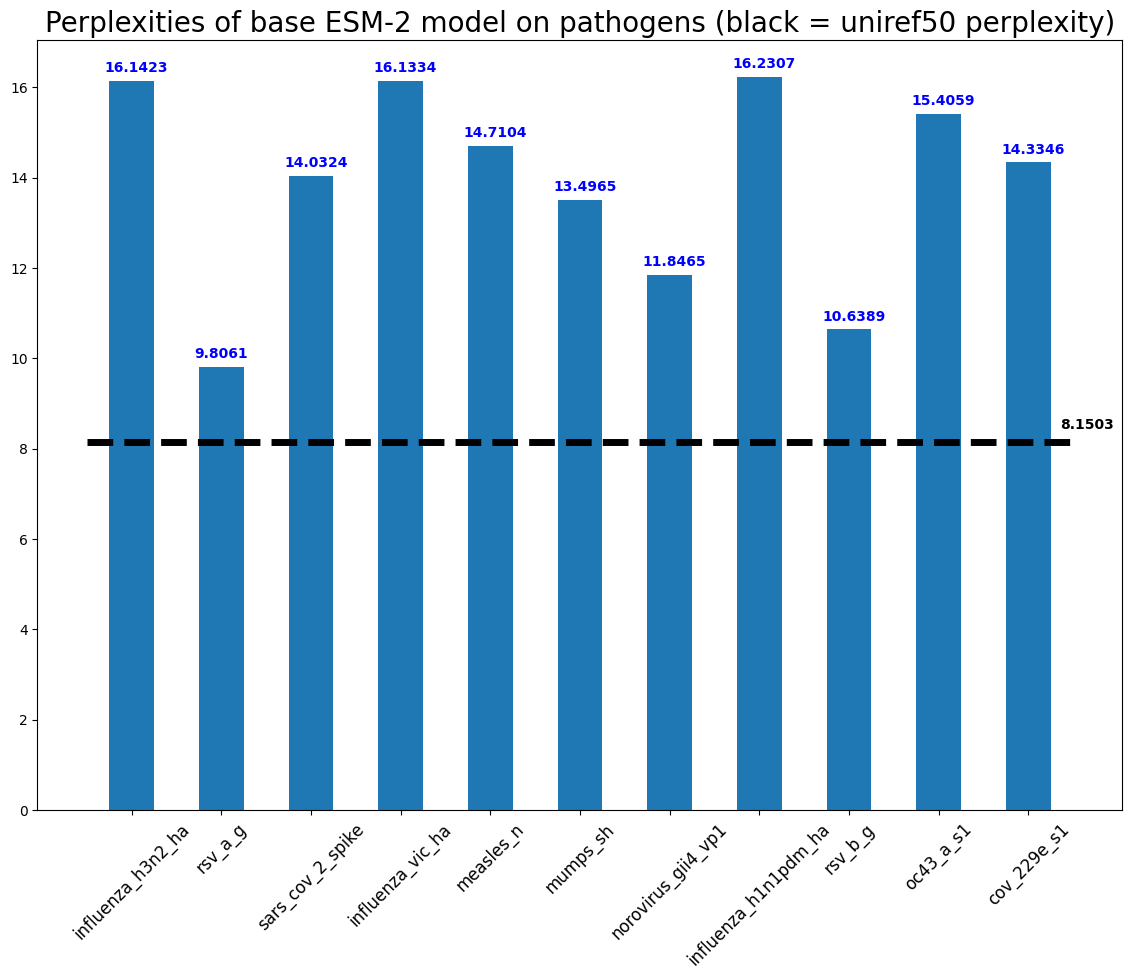

In [32]:
fig, ax = plt.subplots(1,1,figsize=(14,10))
ax.set_title("Perplexities of base ESM-2 model on pathogens (black = uniref50 perplexity)",fontsize=20)
ax.bar(x=pathogens, height=[pathogen_perplexities[p] for p in pathogens], width=0.5)
ax.tick_params("x", rotation=45, labelsize=12)
ax.plot([-0.5,10.5], [pathogen_perplexities["uniref50"] for _ in range(2)], linestyle="dashed", color="black", linewidth=5)
for i,v in enumerate([pathogen_perplexities[p] for p in pathogens]):
    ax.text(i-0.3, v+0.2, f"{v:.4f}", color='blue', fontweight='bold')

ax.text(len(pathogens) - 0.65, pathogen_perplexities["uniref50"] + .3, f"{pathogen_perplexities['uniref50']:.4f}", color="black", fontweight="bold")
fig.show()